Mini-projet : Stratégie marketing

Mini-projet : Analyse de données pour la stratégie marketing

In [ ]:
#Chargement et prétraitement

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Le fichier est un .xls, on utilise read_excel au lieu de read_csv
df = pd.read_excel('US Superstore data.xls')

# Conversion des colonnes de dates en format datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

# Suppression des doublons
df = df.drop_duplicates()

# Vérification rapide
print("Dimensions :", df.shape)
print("Valeurs manquantes :\n", df.isnull().sum())
print(df.head())

Dimensions : (9994, 21)
Valeurs manquantes :
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ... 

C:\Users\big\AppData\Local\Temp\ipykernel_14960\3582956493.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_sales.values[:15], y=state_sales.index[:15], palette='Blues_r')


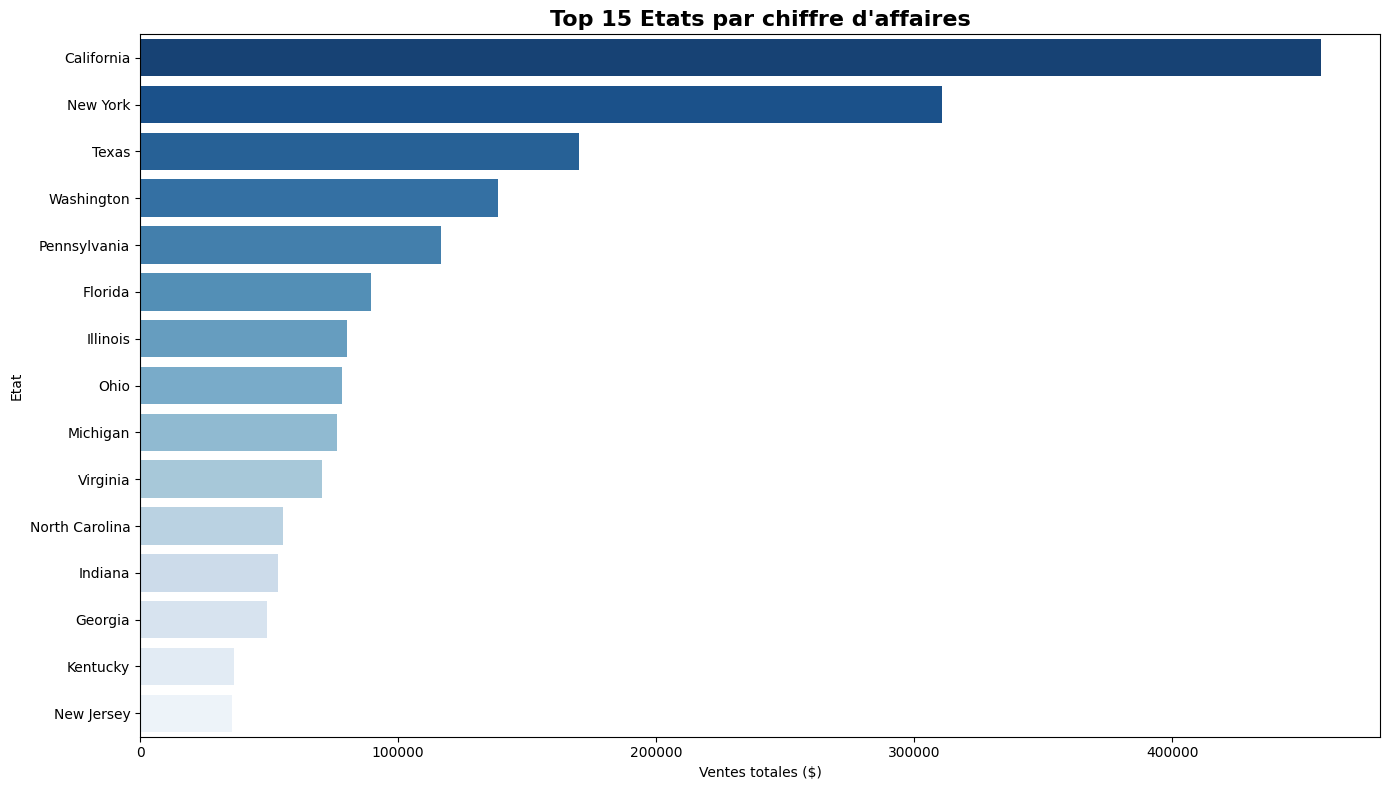

Top 5 etats :
State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Name: Sales, dtype: float64


In [4]:
#Quels états enregistrent le plus de ventes ?

# On regroupe les ventes par état et on trie du plus grand au plus petit
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 8))

# On affiche uniquement les 15 premiers états pour garder le graphique lisible
sns.barplot(x=state_sales.values[:15], y=state_sales.index[:15], palette='Blues_r')

plt.title('Top 15 Etats par chiffre d\'affaires', fontsize=16, fontweight='bold')
plt.xlabel('Ventes totales ($)')
plt.ylabel('Etat')
plt.tight_layout()
plt.show()

print("Top 5 etats :")
print(state_sales.head())

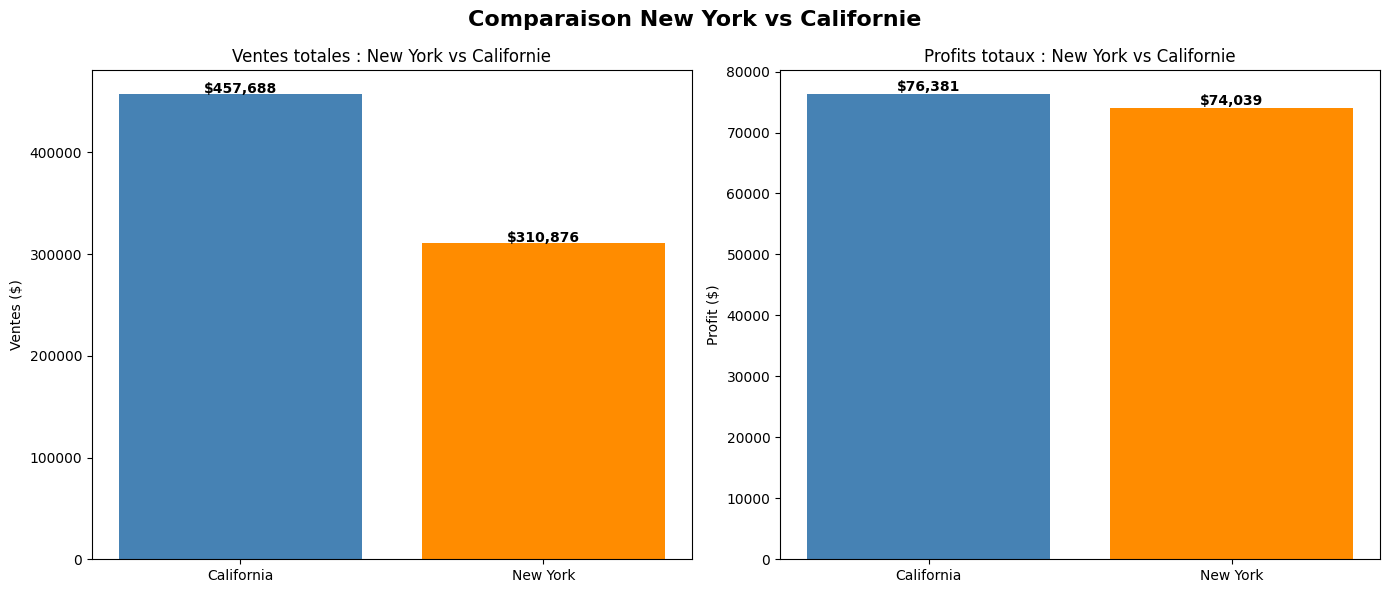

In [5]:
#Comparaison New York vs Californie

# On filtre uniquement les lignes correspondant aux deux états à comparer
ny_ca = df[df['State'].isin(['New York', 'California'])]

# On calcule les ventes et profits totaux pour chaque état
comparison = ny_ca.groupby('State')[['Sales', 'Profit']].sum().reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Graphique des ventes
ax1.bar(comparison['State'], comparison['Sales'], color=['steelblue', 'darkorange'])
ax1.set_title('Ventes totales : New York vs Californie')
ax1.set_ylabel('Ventes ($)')

# On affiche les valeurs au dessus de chaque barre
for i, val in enumerate(comparison['Sales']):
    ax1.text(i, val + 1000, f'${val:,.0f}', ha='center', fontweight='bold')

# Graphique des profits
ax2.bar(comparison['State'], comparison['Profit'], color=['steelblue', 'darkorange'])
ax2.set_title('Profits totaux : New York vs Californie')
ax2.set_ylabel('Profit ($)')

for i, val in enumerate(comparison['Profit']):
    ax2.text(i, val + 500, f'${val:,.0f}', ha='center', fontweight='bold')

plt.suptitle('Comparaison New York vs Californie', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


C:\Users\big\AppData\Local\Temp\ipykernel_14960\1208471213.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ny_top['Sales'], y=ny_top.index, palette='viridis')


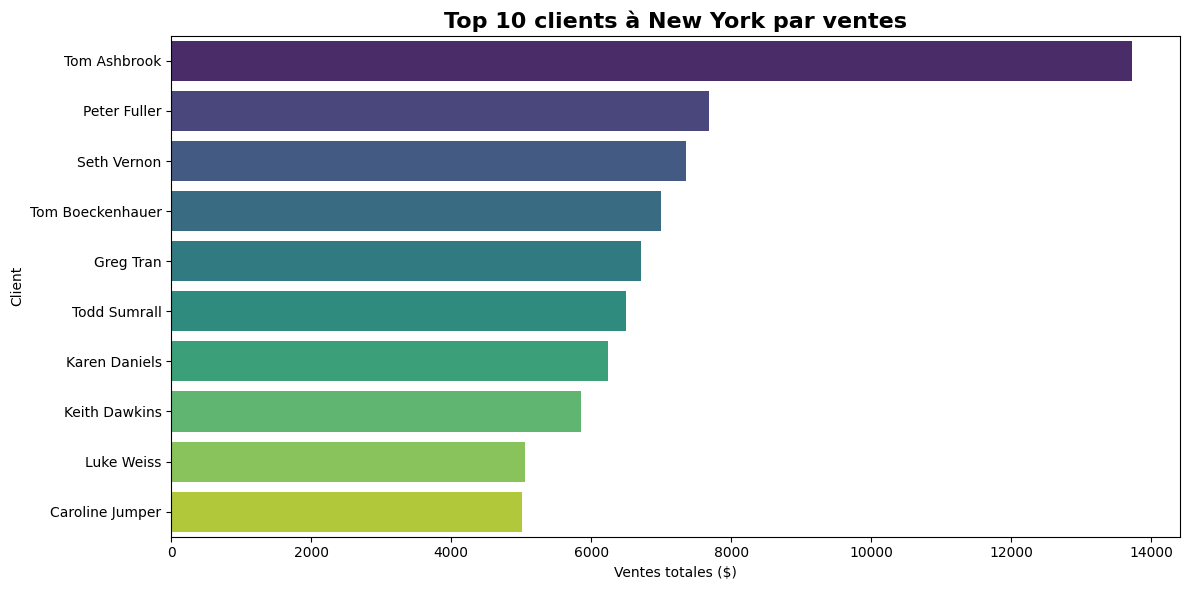

Client exceptionnel a New York :
                   Sales     Profit
Customer Name                      
Tom Ashbrook   13723.498  4599.2073


In [6]:
#Client exceptionnel à New York

# On filtre uniquement les clients de New York
ny_customers = df[df['State'] == 'New York']

# On regroupe par client et on calcule ventes + profits
ny_top = (ny_customers.groupby('Customer Name')[['Sales', 'Profit']]
                       .sum()
                       .sort_values('Sales', ascending=False)
                       .head(10))

plt.figure(figsize=(12, 6))
sns.barplot(x=ny_top['Sales'], y=ny_top.index, palette='viridis')
plt.title('Top 10 clients à New York par ventes', fontsize=16, fontweight='bold')
plt.xlabel('Ventes totales ($)')
plt.ylabel('Client')
plt.tight_layout()
plt.show()

print("Client exceptionnel a New York :")
print(ny_top.head(1))

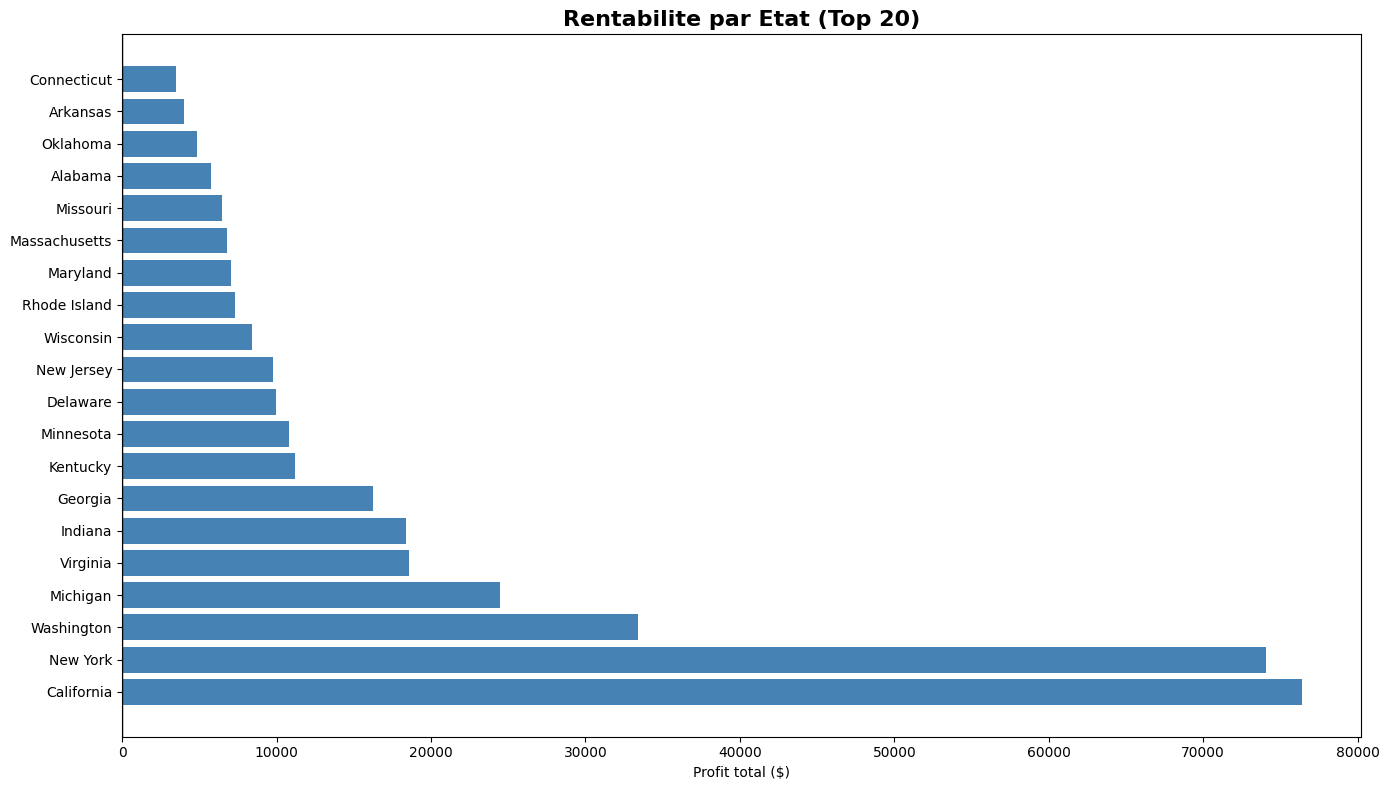

Etats en perte : ['Oregon', 'Florida', 'Arizona', 'Tennessee', 'Colorado', 'North Carolina', 'Illinois', 'Pennsylvania', 'Ohio', 'Texas']


In [7]:
#Différences de rentabilité entre états


# On calcule le profit total par état
state_profit = df.groupby('State')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 8))

# On colorie en rouge les états avec un profit négatif (en perte)
colors = ['red' if x < 0 else 'steelblue' for x in state_profit.values[:20]]
plt.barh(state_profit.index[:20], state_profit.values[:20], color=colors)

plt.axvline(x=0, color='black', linewidth=1)  # ligne verticale à zéro
plt.title('Rentabilite par Etat (Top 20)', fontsize=16, fontweight='bold')
plt.xlabel('Profit total ($)')
plt.tight_layout()
plt.show()

# On identifie les états en perte
etats_en_perte = state_profit[state_profit < 0]
print(f"Etats en perte : {list(etats_en_perte.index)}")

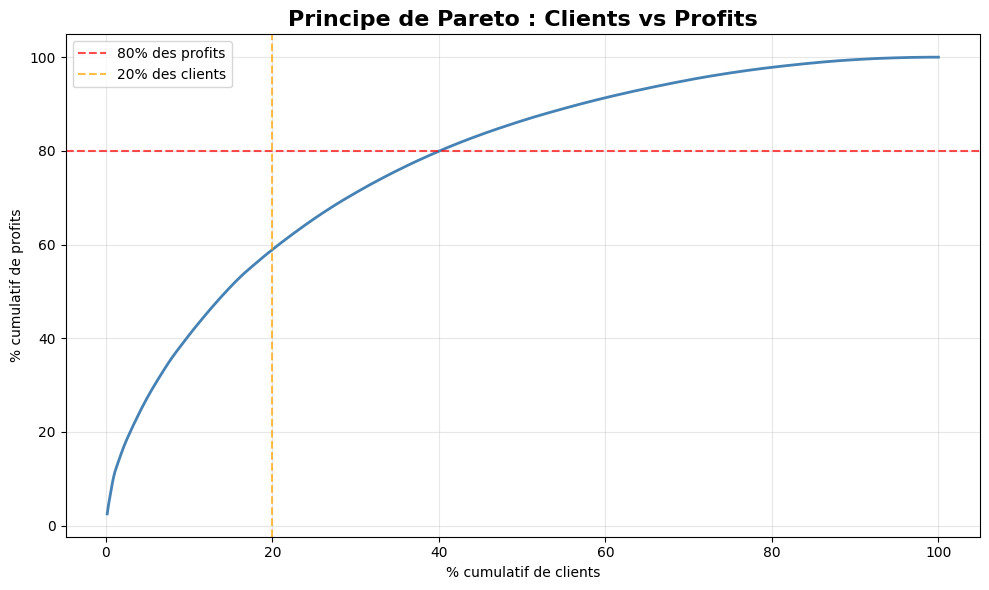

40.1% des clients generent 80% des profits
Pareto verifie ? NON, mais tendance similaire


In [8]:
#Principe de Pareto sur les clients et bénéfices


# On calcule le profit par client, trié du plus rentable au moins rentable
customer_profit = (df.groupby('Customer Name')['Profit']
                     .sum()
                     .sort_values(ascending=False))

# On garde uniquement les clients avec un profit positif
customer_profit = customer_profit[customer_profit > 0]

# cumsum() additionne progressivement les profits
# on divise par le total pour obtenir un pourcentage cumulatif
cumulative_profit = customer_profit.cumsum() / customer_profit.sum() * 100

# On calcule le pourcentage cumulatif de clients
cumulative_customers = np.arange(1, len(customer_profit) + 1) / len(customer_profit) * 100

plt.figure(figsize=(10, 6))
plt.plot(cumulative_customers, cumulative_profit, color='steelblue', linewidth=2)

# Lignes de référence pour visualiser le seuil 80/20
plt.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% des profits')
plt.axvline(x=20, color='orange', linestyle='--', alpha=0.7, label='20% des clients')

plt.title('Principe de Pareto : Clients vs Profits', fontsize=16, fontweight='bold')
plt.xlabel('% cumulatif de clients')
plt.ylabel('% cumulatif de profits')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# On cherche combien de % de clients atteignent 80% des profits
idx_80 = np.where(cumulative_profit >= 80)[0][0]
pct_clients = cumulative_customers[idx_80]
print(f"{pct_clients:.1f}% des clients generent 80% des profits")
print(f"Pareto verifie ?" , "OUI" if pct_clients <= 25 else "NON, mais tendance similaire")

C:\Users\big\AppData\Local\Temp\ipykernel_14960\3155808743.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_sales.values, y=city_sales.index, palette='Blues_r', ax=ax1)


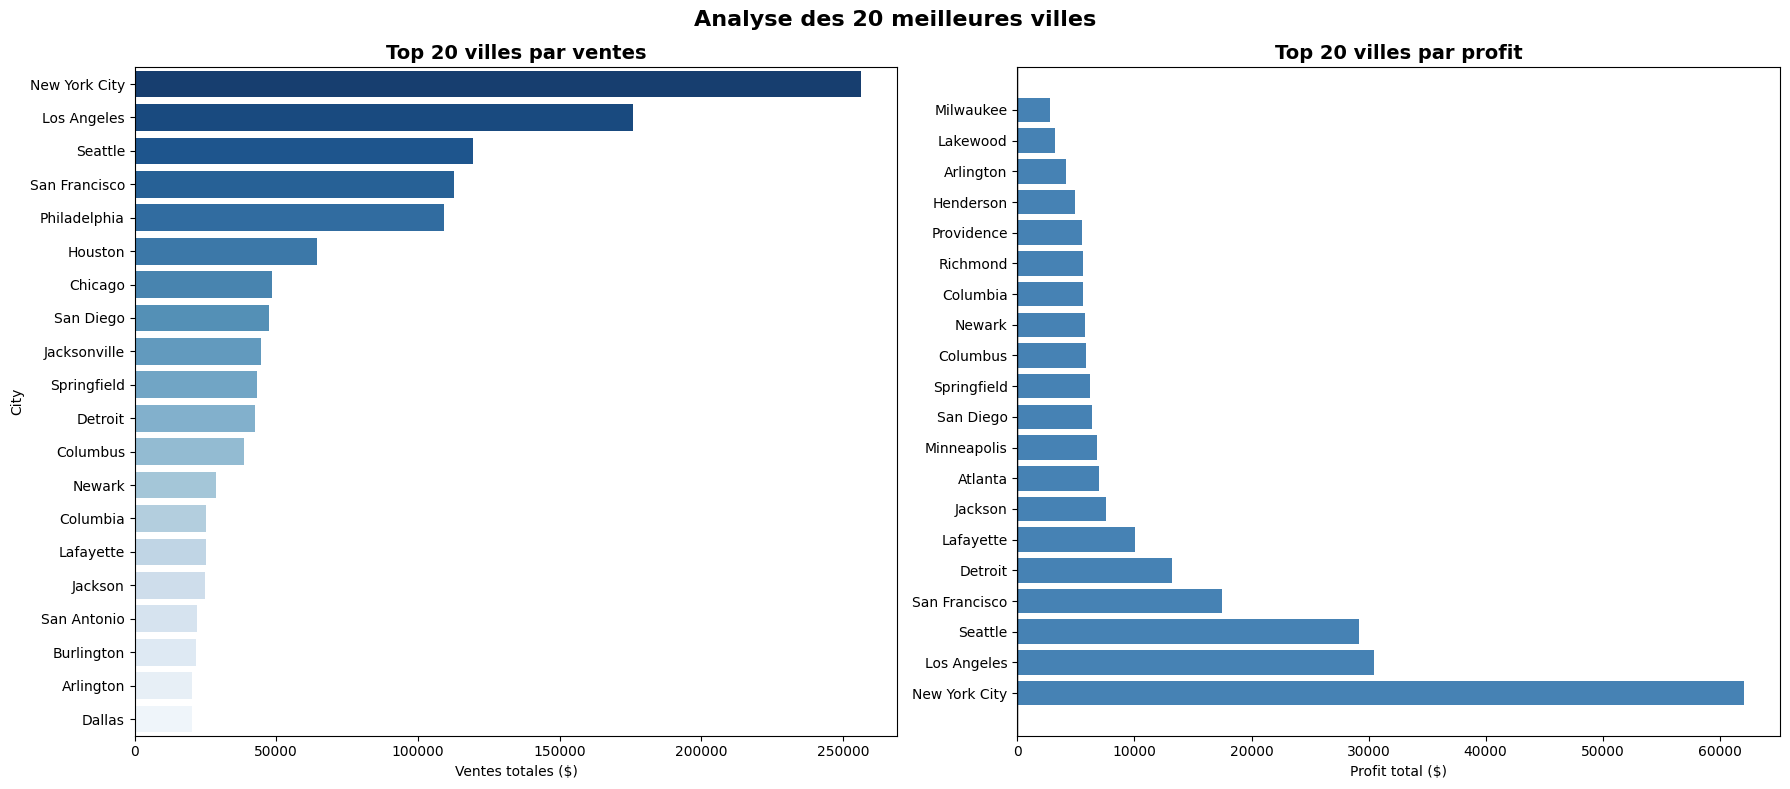

Villes top ventes mais en perte : {'Houston', 'Philadelphia', 'Chicago', 'Dallas', 'San Antonio', 'Jacksonville', 'Burlington'}


In [9]:
#Top 20 villes par ventes et profits

# On calcule ventes et profits par ville
city_sales  = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(20)
city_profit = df.groupby('City')['Profit'].sum().sort_values(ascending=False).head(20)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Graphique des ventes
sns.barplot(x=city_sales.values, y=city_sales.index, palette='Blues_r', ax=ax1)
ax1.set_title('Top 20 villes par ventes', fontsize=14, fontweight='bold')
ax1.set_xlabel('Ventes totales ($)')

# Graphique des profits
# On colorie en rouge les villes en perte
colors = ['red' if x < 0 else 'steelblue' for x in city_profit.values]
ax2.barh(city_profit.index, city_profit.values, color=colors)
ax2.axvline(x=0, color='black', linewidth=1)
ax2.set_title('Top 20 villes par profit', fontsize=14, fontweight='bold')
ax2.set_xlabel('Profit total ($)')

plt.suptitle('Analyse des 20 meilleures villes', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Villes dans le top 20 ventes mais avec un profit négatif = risque marketing
top20_ventes = set(city_sales.index)
villes_en_perte = set(df.groupby('City')['Profit'].sum()[
    df.groupby('City')['Profit'].sum() < 0].index)
risque = top20_ventes & villes_en_perte

print(f"Villes top ventes mais en perte : {risque}")


C:\Users\big\AppData\Local\Temp\ipykernel_14960\1648883971.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=customer_sales.values, y=customer_sales.index, palette='viridis')


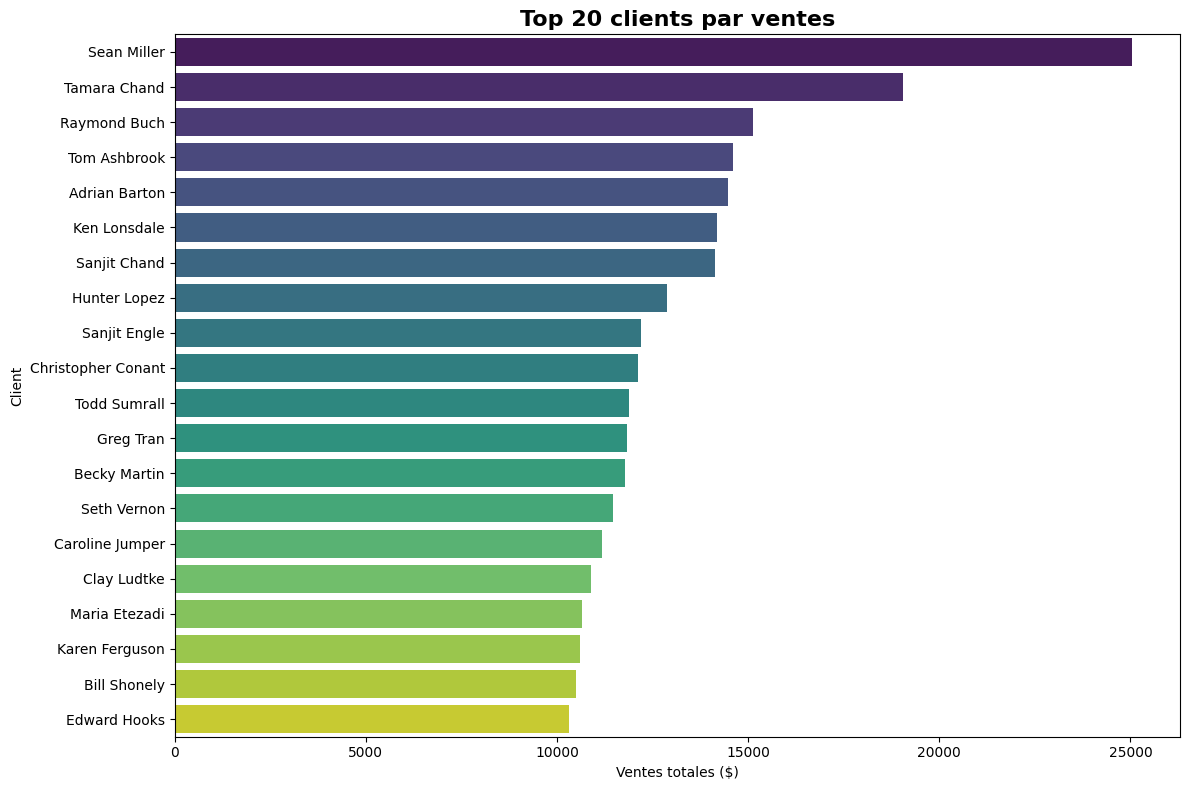

In [10]:
#Top 20 clients par ventes

customer_sales = (df.groupby('Customer Name')['Sales']
                    .sum()
                    .sort_values(ascending=False)
                    .head(20))

plt.figure(figsize=(12, 8))
sns.barplot(x=customer_sales.values, y=customer_sales.index, palette='viridis')
plt.title('Top 20 clients par ventes', fontsize=16, fontweight='bold')
plt.xlabel('Ventes totales ($)')
plt.ylabel('Client')
plt.tight_layout()
plt.show()


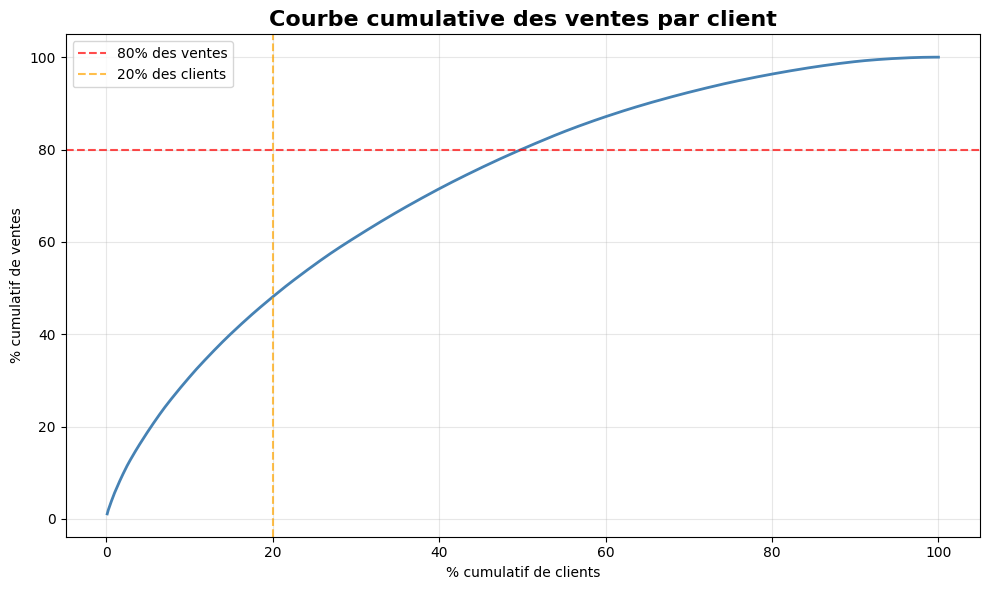

49.9% des clients generent 80% des ventes


In [11]:
#Courbe cumulative des ventes par client (Pareto ventes)

all_customer_sales = (df.groupby('Customer Name')['Sales']
                        .sum()
                        .sort_values(ascending=False))

cumulative_sales     = all_customer_sales.cumsum() / all_customer_sales.sum() * 100
cumulative_customers = np.arange(1, len(all_customer_sales) + 1) / len(all_customer_sales) * 100

plt.figure(figsize=(10, 6))
plt.plot(cumulative_customers, cumulative_sales.values, color='steelblue', linewidth=2)
plt.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% des ventes')
plt.axvline(x=20, color='orange', linestyle='--', alpha=0.7, label='20% des clients')

plt.title('Courbe cumulative des ventes par client', fontsize=16, fontweight='bold')
plt.xlabel('% cumulatif de clients')
plt.ylabel('% cumulatif de ventes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

idx_80 = np.where(cumulative_sales.values >= 80)[0][0]
pct_clients = cumulative_customers[idx_80]
print(f"{pct_clients:.1f}% des clients generent 80% des ventes")


In [13]:
#Conclusion et recommandations marketing


print(" RECOMMANDATIONS MARKETING\n")

top5_states = state_sales.head(5)
print("Etats prioritaires (top 5 ventes) :")
for state, sales in top5_states.items():
    profit = df[df['State'] == state]['Profit'].sum()
    print(f"  - {state} : ventes = ${sales:,.0f} | profit = ${profit:,.0f}")

print("\nVilles prioritaires (top 5 ventes) :")
for city, sales in city_sales.head(5).items():
    profit = df[df['City'] == city]['Profit'].sum()
    print(f"  - {city} : ventes = ${sales:,.0f} | profit = ${profit:,.0f}")

print("\nClients VIP à fidéliser (top 5) :")
print(customer_sales.head(5).to_string())

 RECOMMANDATIONS MARKETING

Etats prioritaires (top 5 ventes) :
  - California : ventes = $457,688 | profit = $76,381
  - New York : ventes = $310,876 | profit = $74,039
  - Texas : ventes = $170,188 | profit = $-25,729
  - Washington : ventes = $138,641 | profit = $33,403
  - Pennsylvania : ventes = $116,512 | profit = $-15,560

Villes prioritaires (top 5 ventes) :
  - New York City : ventes = $256,368 | profit = $62,037
  - Los Angeles : ventes = $175,851 | profit = $30,441
  - Seattle : ventes = $119,541 | profit = $29,156
  - San Francisco : ventes = $112,669 | profit = $17,507
  - Philadelphia : ventes = $109,077 | profit = $-13,838

Clients VIP à fidéliser (top 5) :
Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
